In [13]:
from src.myio import reader,  read_gpkg, read_csv, write_parquet, read_dem, read_parquet


In [14]:
from pathlib import Path


In [15]:
reader = reader("DATA_UTM/dem")

dem_root = Path(reader.full_path)

In [16]:
dem_paths = list(dem_root.rglob("*.tif"))  # або просто "*.tif" якщо потрібно всі
print(dem_paths)

[PosixPath('/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/alos_dem_utm32635.tif'), PosixPath('/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/aster_dem_utm32635.tif'), PosixPath('/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/copernicus_dеm_utm32635.tif'), PosixPath('/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/fab_dem_utm32635.tif'), PosixPath('/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/nasa_dem_utm32635.tif'), PosixPath('/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/srtm_dem_utm32635.tif'), PosixPath('/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/tan_dem_utm32635.tif')]


In [27]:
import xdem

In [29]:
from xdem.terrain import get_terrain_attribute

for path in dem_paths:
    print(path)
    dem = xdem.DEM(path)
    print(dem)

    # slope = get_terrain_attribute(dem.data, dem.transform, attribute="slope")
    # print(f"{path.name}: slope mean = {slope.mean():.2f}°")


/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/alos_dem_utm32635.tif
not_loaded
/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/aster_dem_utm32635.tif
not_loaded
/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/copernicus_dеm_utm32635.tif
not_loaded
/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/fab_dem_utm32635.tif
not_loaded
/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/nasa_dem_utm32635.tif
not_loaded
/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/srtm_dem_utm32635.tif
not_loaded
/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/tan_dem_utm32635.tif
not_loaded



📂 alos_dem_utm32635.tif


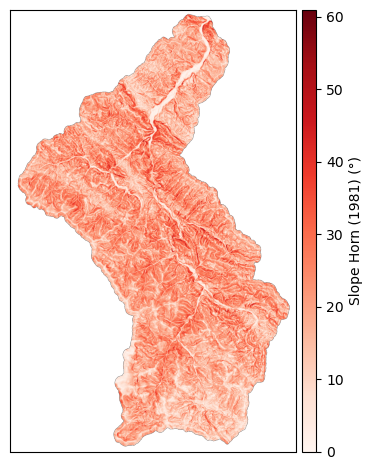

💾 Збережено: alos_dem_utm32635_slope_horn.tif

📂 aster_dem_utm32635.tif


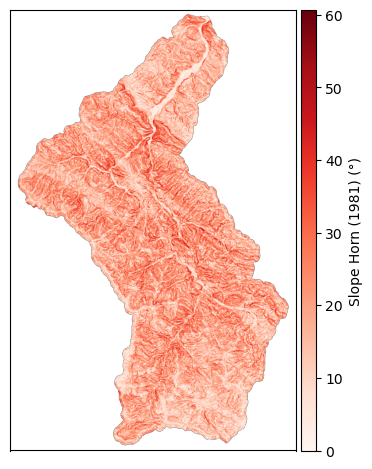

💾 Збережено: aster_dem_utm32635_slope_horn.tif

📂 copernicus_dеm_utm32635.tif


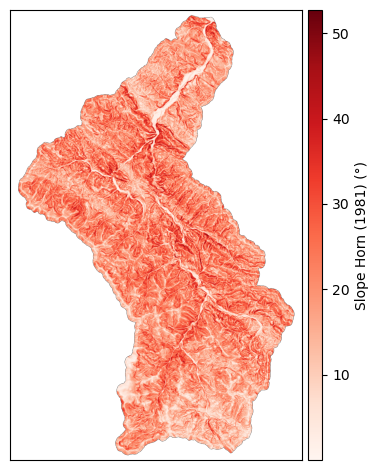

💾 Збережено: copernicus_dеm_utm32635_slope_horn.tif

📂 fab_dem_utm32635.tif


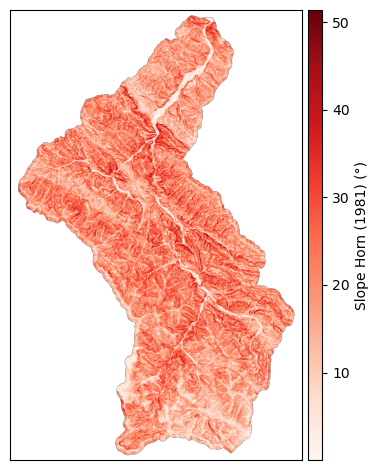

💾 Збережено: fab_dem_utm32635_slope_horn.tif

📂 nasa_dem_utm32635.tif


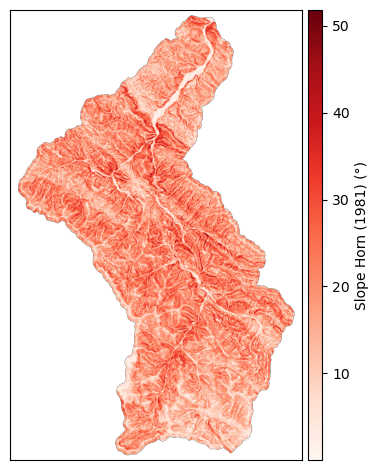

💾 Збережено: nasa_dem_utm32635_slope_horn.tif

📂 srtm_dem_utm32635.tif


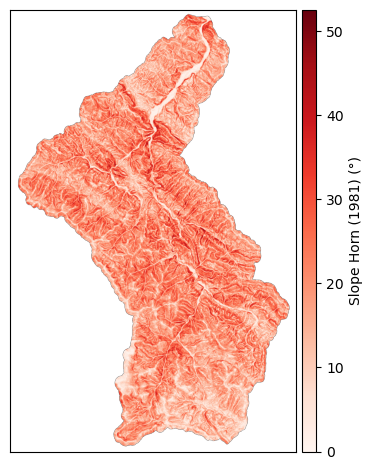

💾 Збережено: srtm_dem_utm32635_slope_horn.tif

📂 tan_dem_utm32635.tif


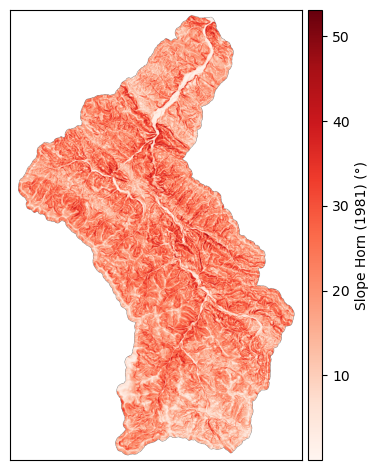

💾 Збережено: tan_dem_utm32635_slope_horn.tif


In [44]:
from pathlib import Path
import xdem
from xdem.terrain import slope
import matplotlib.pyplot as plt
import numpy as np
import rasterio


def plot_attribute(attribute, cmap, label=None, vlim=None):
    if vlim is not None:
        if isinstance(vlim, (int, float)):
            vlims = {"vmin": -vlim, "vmax": vlim}
        elif isinstance(vlim, (list, tuple)) and len(vlim) == 2:
            vlims = {"vmin": vlim[0], "vmax": vlim[1]}
        else:
            vlims = {}
    else:
        vlims = {}

    attribute.plot(cmap=cmap, cbar_title=label, **vlims)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()





# === Прохід по DEM ===
for path in dem_paths:
    print(f"\n📂 {path.name}")

    dem = xdem.DEM(path)

    # Схил методом Horn (за замовчуванням)
    slope_horn = slope(dem, method="Horn")
    plot_attribute(slope_horn, "Reds", "Slope Horn (1981) (°)")

    # Відкриваємо оригінальний DEM через rasterio
    with rasterio.open(path) as src:
        profile = src.profile

    # Оновлюємо профіль для slope
    profile.update(dtype="float32", count=1)

    # Шлях до файлу збереження
    slope_path = path.with_name(path.stem + "_slope_horn.tif")

    # Записуємо slope у GeoTIFF
    with rasterio.open(slope_path, "w", **profile) as dst:
        dst.write(slope_horn.data.astype("float32"), 1)

    print(f"💾 Збережено: {slope_path.name}")


